<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/13_QC_%E1%84%87%E1%85%A2%E1%84%8E%E1%85%B5%E1%84%89%E1%85%AE%E1%84%8B%E1%85%B2%E1%86%AF%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8_OOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 13 · 배치 수율 예측 & OOS 조기경보
### 발효/합성 공정 데이터로 품질을 미리 예측 (QC/GMP 현장)


의약품 제조에서 한 **배치(batch)** 의 수율·역가가 규격을 벗어나면(**OOS, Out-Of-Specification**)
막대한 손실과 조사(investigation)가 발생합니다.
공정 중 센서값(온도·pH·산소·교반 등)으로 **최종 품질을 미리 예측**하면,
문제 배치를 **일찍 잡아** 조치할 수 있습니다. 이것이 스마트 제조/PAT 의 핵심입니다.

> 데이터는 **페니실린 발효 공정(IndPenSim)** 을 본뜬 현실적 시뮬레이션을 사용합니다.
> (실제 IndPenSim 공개데이터: 100 batches, 수십 개 공정변수)


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(42)

# ---- 페니실린 발효 배치 데이터 생성 (공정변수 → 최종 수율) ----
# 실제 현장에서 얻는 배치별 공정 요약값을 모사
N = 500
temp   = np.random.normal(26, 1.2, N)      # 발효 온도(°C)
pH     = np.random.normal(6.5, 0.25, N)    # pH
DO     = np.random.normal(45, 8, N)        # 용존산소(%)
agit   = np.random.normal(200, 25, N)      # 교반속도(rpm)
feed   = np.random.normal(0.08, 0.02, N)   # 기질 공급속도
dur    = np.random.normal(180, 12, N)      # 발효시간(h)

# 수율(g/L): 각 공정변수의 비선형 영향 + 잡음 (온도/ pH 최적점 존재)
yield_ = (35
    - 2.2*(temp-26)**2          # 26도에서 최대
    - 8.0*(pH-6.6)**2           # pH 6.6 근처 최적
    + 0.05*(DO-40)
    + 0.02*(agit-180)
    + 60*(feed-0.05)
    + 0.03*(dur-170)
    + np.random.normal(0, 1.2, N))

df = pd.DataFrame({"온도":temp,"pH":pH,"용존산소":DO,"교반":agit,
                   "공급속도":feed,"발효시간":dur,"수율":yield_})
print("배치 수:", len(df))
df.head()

배치 수: 500


,온도,pH,용존산소,교반,공급속도,발효시간,수율
0,26.596057,6.731544,56.194843,219.459027,0.066496,186.847356,34.884704
1,25.834083,6.977354,52.397069,186.220357,0.077110,191.618216,35.787191
2,26.777226,6.150358,45.477043,179.545028,0.064152,176.024299,32.851851
3,27.827636,6.640742,39.824506,199.915639,0.073841,172.653159,31.802969
4,25.719016,6.337339,50.585787,195.745384,0.042128,166.978194,35.223450


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,676 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


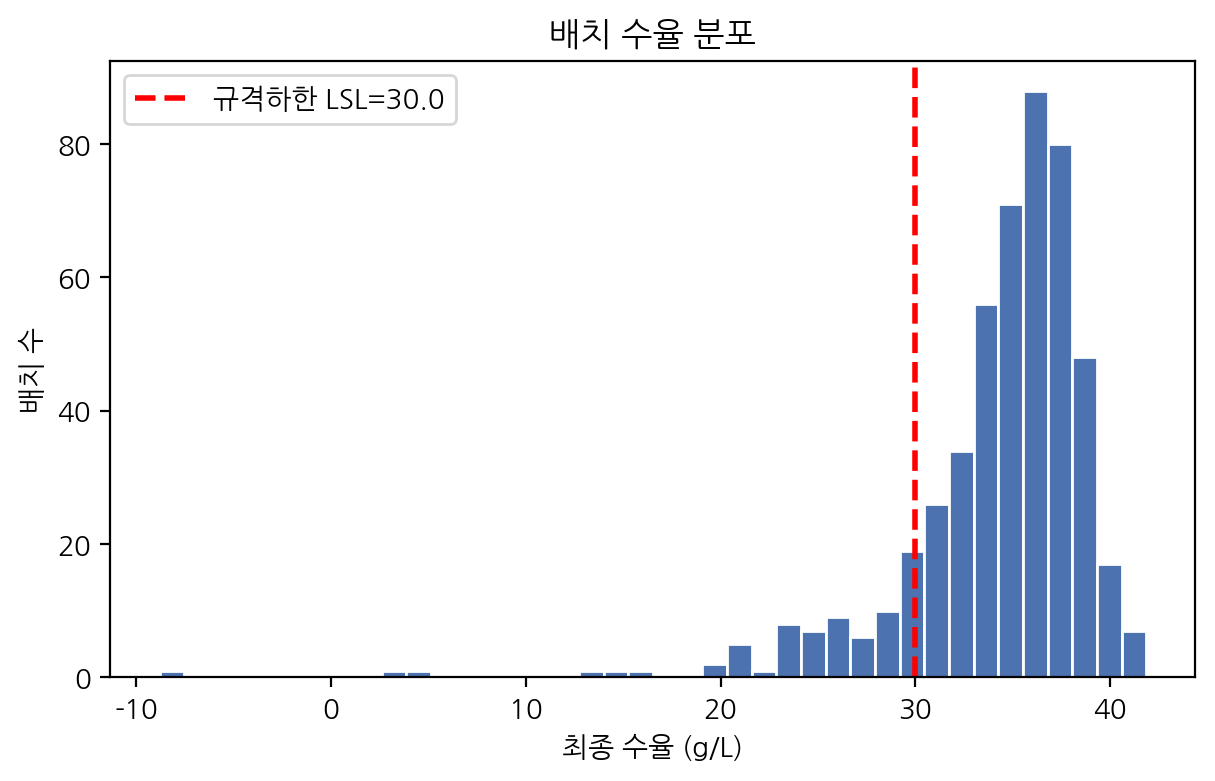

OOS(불합격) 배치 비율: 13.6%


In [2]:
# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# 수율 분포와 규격하한(LSL) 표시 — 이 아래로 떨어지면 OOS
LSL = 30.0   # 규격하한 (예: 30 g/L 미만이면 불합격)
plt.figure(figsize=(7,4))
plt.hist(df["수율"], bins=40, color="#4C72B0", edgecolor="white")
plt.axvline(LSL, color="red", ls="--", lw=2, label=f"규격하한 LSL={LSL}")
plt.xlabel("최종 수율 (g/L)"); plt.ylabel("배치 수"); plt.legend()
plt.title("배치 수율 분포"); plt.show()
print("OOS(불합격) 배치 비율:", f"{(df['수율']<LSL).mean():.1%}")

## 1. 회귀: 공정변수로 최종 수율 예측
공정이 끝나기 전(또는 초기 센서값)으로 **최종 수율을 예측**합니다.


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(columns="수율"); y = df["수율"]
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)
reg = RandomForestRegressor(n_estimators=400, random_state=42).fit(Xtr,ytr)
pred = reg.predict(Xte)
print("수율 예측 R²  :", round(r2_score(yte,pred),3))
print("수율 예측 RMSE:", round(mean_squared_error(yte,pred)**0.5,3), "g/L")

수율 예측 R²  : 0.769
수율 예측 RMSE: 3.162 g/L


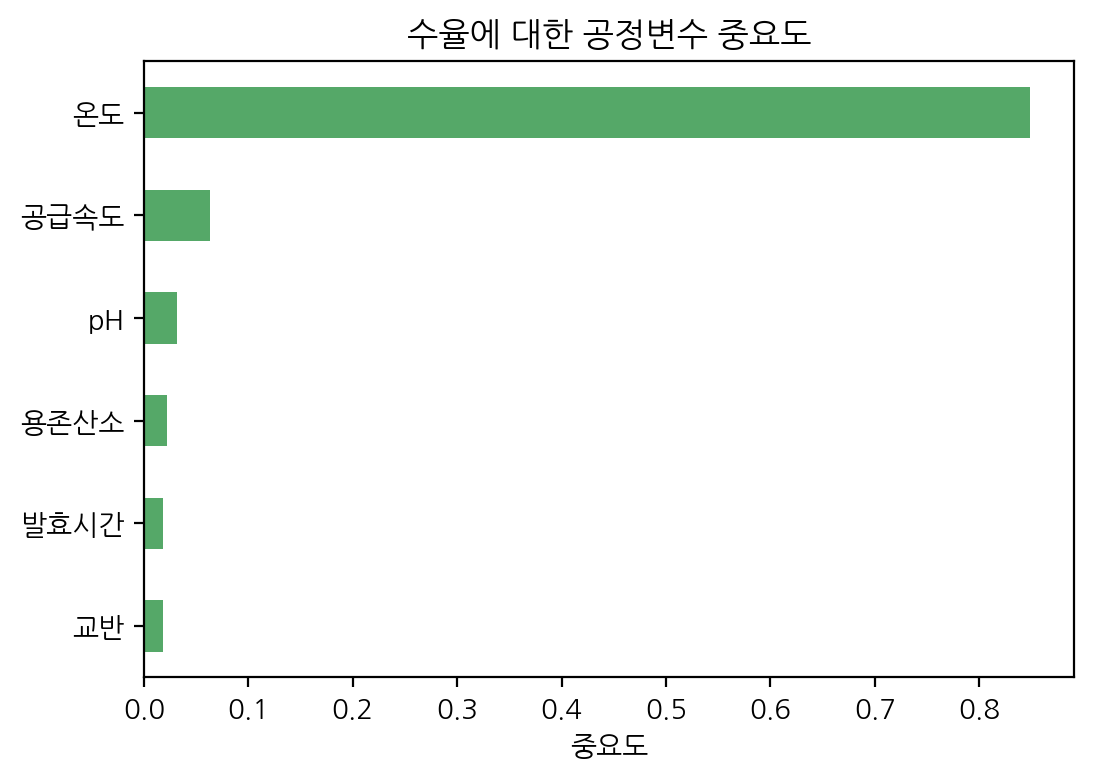

→ 중요도 높은 변수를 집중 관리하면 수율 안정화 가능


In [4]:
# 어떤 공정변수가 수율을 좌우하는가 → 현장 개선 포인트
imp = pd.Series(reg.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(6,4), color="#55A868")
plt.title("수율에 대한 공정변수 중요도"); plt.xlabel("중요도"); plt.show()
print("→ 중요도 높은 변수를 집중 관리하면 수율 안정화 가능")

## 2. ⭐ OOS(규격이탈) 조기경보 — 분류 문제로 전환
"수율 몇 g/L?"(회귀) 대신 **"이 배치가 불합격(OOS)일까?"(분류)** 로 바꾸면
현장에서 **경보 시스템**으로 바로 쓸 수 있습니다.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df["OOS"] = (df["수율"] < LSL).astype(int)   # 1=불합격
Xc = df.drop(columns=["수율","OOS"]); yc = df["OOS"]
Xtr,Xte,ytr,yte = train_test_split(Xc,yc,test_size=0.2,random_state=42,stratify=yc)

clf = RandomForestClassifier(n_estimators=400, class_weight="balanced",
                             random_state=42).fit(Xtr,ytr)
pred = clf.predict(Xte); proba = clf.predict_proba(Xte)[:,1]
print(confusion_matrix(yte,pred))
print(classification_report(yte,pred,target_names=["합격","OOS(불합격)"]))
print("ROC-AUC:", round(roc_auc_score(yte,proba),3))

[[82  4]
 [ 7  7]]
              precision    recall  f1-score   support

          합격       0.92      0.95      0.94        86
    OOS(불합격)       0.64      0.50      0.56        14

    accuracy                           0.89       100
   macro avg       0.78      0.73      0.75       100
weighted avg       0.88      0.89      0.88       100

ROC-AUC: 0.959


### 재현율(Recall)이 중요한 이유
OOS 배치를 **놓치면(=합격으로 잘못 판정)** 불량품이 출하될 위험이 있습니다.
따라서 OOS 클래스의 **재현율**을 높게 유지하는 것이 품질안전상 핵심입니다.
`class_weight="balanced"` 로 소수 클래스(OOS)에 가중치를 줬습니다.


In [ ]:
# 위험 배치 우선순위: OOS 확률이 높은 순으로 정렬 → QC 팀이 집중 검토
risk = Xte.copy()
risk["OOS확률"] = proba
risk.sort_values("OOS확률", ascending=False).head(10).round(2)

,온도,pH,용존산소,교반,공급속도,발효시간,OOS확률
113,28.96,6.22,48.97,198.05,0.06,179.92,0.85
13,23.70,6.27,39.49,153.34,0.06,176.94,0.74
31,28.22,6.08,31.65,155.79,0.06,168.88,0.69
234,28.57,6.76,38.57,220.00,0.06,203.84,0.64
396,23.94,6.46,34.22,193.53,0.06,154.99,0.63
23,24.29,6.64,62.14,176.01,0.05,176.24,0.59
474,27.97,6.39,38.72,199.53,0.09,190.94,0.58
209,30.62,6.92,59.00,175.64,0.08,198.76,0.56
482,24.07,6.26,58.82,184.33,0.12,188.79,0.54
189,24.18,6.61,37.25,193.53,0.09,187.35,0.53


## 정리 & 현장 응용
- 공정 센서값 → 최종 품질 **예측(회귀)** & **OOS 조기경보(분류)** 동시 구현
- 변수 중요도로 **관리해야 할 핵심 공정변수** 파악
- 확률 기반 **위험 배치 우선순위**로 QC 자원 효율 배분
- 실제 적용: 발효·정제·합성·동결건조 등 배치 공정 전반
